# Analyse du refroidisseur d'acide de sechage E7301

**Atelier Sulfurique PS III — Maroc Chimie, OCP Group**
Mounir Sanbouli — Stage OCP, Programme Bionic

---

Ce notebook justifie, etape par etape, les choix de conception du systeme de
surveillance. Il ne se contente pas de tracer des courbes : chaque section
repond a une question qui a determine une decision technique.

1. Que contiennent reellement les donnees ?
2. Quels capteurs peut-on croire ?
3. Pourquoi une approche statistique classique echoue-t-elle ici ?
4. Comment le jumeau thermique resout-il le probleme ?
5. Que detecte le systeme sur 14 mois ?
6. Le Judge merite-t-il qu'on lui fasse confiance ?

In [1]:
import sys, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (13, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10,
})

from src.config import DATA_DIR
from src.domain.knowledge import load_domain
from src.ingest.dcs_loader import ingest

domain = load_domain()
print(domain.briefing_equipment())

REFROIDISSEUR D'ACIDE DE SECHAGE — S-PC-E7301 (E7301)
Constructeur CHEMETICS, size 1118-9754, mis en production le 2015-11-01.
Atelier PS III, site Maroc Chimie.
Echangeur a faisceau tubulaire : acide sulfurique de sechage cote calandre, eau de mer cote tubes. Tubes en 904L, protection anodique par plaques sacrificielles.


## 1. Que contiennent reellement les donnees ?

L'export DCS ne s'accompagne d'aucun dictionnaire de tags. L'interpretation a ete
reconstruite a partir de trois sources convergentes : la nomenclature ISA-5.1,
la plage de valeurs observee, et le comportement des signaux lors des arrets.

Chaque interpretation est tracee dans `src/domain/tags.yaml` avec son niveau de
confiance et sa justification — elle est donc contestable et corrigeable par le
tuteur OCP sans toucher au code.

In [2]:
res = ingest(DATA_DIR / "raw" / "DATA.xlsx", domain)
print(res.summary())

for t in domain.monitored_tags:
    print(f"\n{t.alias:14s} [{t.confidence}]  {t.label}")
    print("   " + " ".join(t.rationale.split())[:150])

2026-07-25 12:52:12 | INFO     | src.ingest.dcs_loader:109 - Export DCS lu: 10182 lignes, 12 tags


2026-07-25 12:52:13 | WARNING  | src.ingest.dcs_loader:330 - 2 horodatage(s) duplique(s) — derniere valeur conservee


2026-07-25 12:52:13 | INFO     | src.ingest.dcs_loader:385 - Ingestion terminee — 10180 lignes, 9116 evenements qualite


Periode        : 2024-01-01 07:00:00 -> 2025-02-28 11:00:00
Echantillons   : 10180 (pas nominal 0 days 01:00:00)
Trous temporels: 1   Doublons: 2
Etats process  : RUNNING=8795, SHUTDOWN=1261, TRANSIENT=124
Evenements qualite: 9116

T_ACID_IN      [inferred]  Temperature acide entree refroidisseur
   ISA TI = Temperature Indicator, boucle 1100 = circuit acide de sechage. Mediane 94 degC, s'effondre a l'arret process (fev-2024 : 40 degC). Variable L

T_ACID_OUT     [inferred]  Temperature acide sortie refroidisseur (variable regulee)
   Boucle 1105, aval immediat de 1100. Distribution tres resserree (P1=63.7, P99=66.6 degC) : signature d'une variable sous regulation en boucle fermee. 

F_ACID         [inferred]  Debit acide de sechage
   ISA FI = Flow Indicator. Mediane 56.5, tombe a ~0 a l'arret. Correlation +0.54 avec la charge soufre en marche etablie. LIMITE CONNUE : autocorrelatio

C_ACID_1100    [inferred]  Titre acide sulfurique circuit 1100
   ISA AI = Analyzer Indicator. Mediane

## 2. Quels capteurs peut-on croire ?

Question preliminaire a toute modelisation. Un modele entraine sur un capteur mort
apprend du bruit d'instrumentation et le presente ensuite comme un diagnostic.

In [3]:
h = res.sensor_health
display(h[["alias", "role", "availability_pct", "n_quality_code",
           "n_frozen", "n_saturated", "n_out_of_range"]])

,alias,role,availability_pct,n_quality_code,n_frozen,n_saturated,n_out_of_range
0,TI_5303,degraded,47.81,139,4,5170,0
1,PHI_5306,degraded,85.36,139,1351,0,0
2,C_ACID_1200,primary,93.78,0,118,515,0
3,C_ACID_1100,primary,93.90,0,85,536,0
4,F_3412,context,96.90,0,85,0,231
5,T_ACID_OUT,primary,98.32,0,171,0,0
6,LOAD_SULFUR,context,98.80,0,85,0,37
7,F_ACID,primary,98.96,1,86,0,19
8,A_3302,context,99.15,1,86,0,0
9,A_3301,context,99.15,1,86,0,0


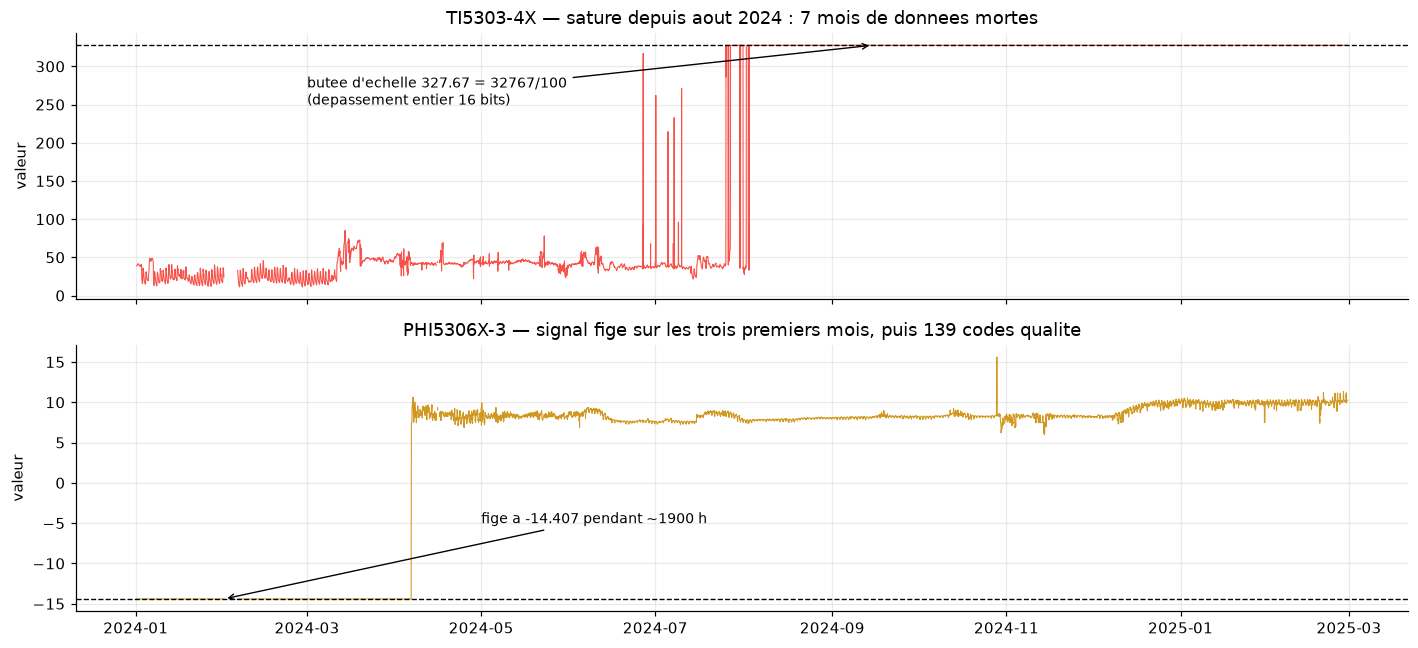

In [4]:
# Les deux defaillances averees, tracees sur toute la periode.
raw = pd.read_excel(DATA_DIR / "raw" / "DATA.xlsx")
raw["TIME"] = pd.to_datetime(raw["TIME"])
raw = raw.set_index("TIME")

fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

s1 = pd.to_numeric(raw["S_MC_SULF_TI5303-4X_B"], errors="coerce")
ax[0].plot(s1.index, s1.values, lw=.7, color="#f85149")
ax[0].axhline(327.67, ls="--", color="k", lw=.9)
ax[0].annotate("butee d'echelle 327.67 = 32767/100\n(depassement entier 16 bits)",
               xy=(pd.Timestamp("2024-09-15"), 327.67), xytext=(pd.Timestamp("2024-03-01"), 250),
               arrowprops=dict(arrowstyle="->", lw=.9), fontsize=9)
ax[0].set_title("TI5303-4X — sature depuis aout 2024 : 7 mois de donnees mortes")
ax[0].set_ylabel("valeur")

s2 = pd.to_numeric(raw["S_MC_SULF_PHI5306X-3_B"], errors="coerce")
ax[1].plot(s2.index, s2.values, lw=.7, color="#d29922")
ax[1].axhline(-14.407, ls="--", color="k", lw=.9)
ax[1].annotate("fige a -14.407 pendant ~1900 h",
               xy=(pd.Timestamp("2024-02-01"), -14.4), xytext=(pd.Timestamp("2024-05-01"), -5),
               arrowprops=dict(arrowstyle="->", lw=.9), fontsize=9)
ax[1].set_title("PHI5306X-3 — signal fige sur les trois premiers mois, puis 139 codes qualite")
ax[1].set_ylabel("valeur")
plt.tight_layout(); plt.show()

In [5]:
# Gel simultane de sept tags en juin 2024 : la simultaneite exclut une panne
# de capteur individuelle et designe une interruption de l'acquisition.
q = res.quality
jun = q[(q.issue == "FROZEN") & (q.timestamp >= "2024-06-01") & (q.timestamp <= "2024-06-15")]
print("Tags figes simultanement du 3 au 10 juin 2024 :")
print(jun.groupby("alias")["timestamp"].agg(["count", "min", "max"]).to_string())

Tags figes simultanement du 3 au 10 juin 2024 :
             count                 min                 max
alias                                                     
A_3301          86 2024-06-03 23:00:00 2024-06-10 11:00:00
A_3302          86 2024-06-03 23:00:00 2024-06-10 11:00:00
C_ACID_1100     85 2024-06-03 23:00:00 2024-06-10 11:00:00
C_ACID_1200     85 2024-06-03 23:00:00 2024-06-10 11:00:00
F_3412          85 2024-06-03 23:00:00 2024-06-10 11:00:00
F_ACID          86 2024-06-03 23:00:00 2024-06-10 11:00:00
LOAD_SULFUR     85 2024-06-03 23:00:00 2024-06-10 11:00:00
T_ACID_IN       85 2024-06-03 23:00:00 2024-06-10 11:00:00
T_ACID_OUT      85 2024-06-03 23:00:00 2024-06-10 11:00:00
T_CIRC_1300     85 2024-06-03 23:00:00 2024-06-10 11:00:00


## 3. Pourquoi une approche statistique classique echoue-t-elle ?

C'est le point de bascule du projet. La temperature de sortie acide est
**regulee** : sa distribution est ecrasee autour de la consigne. Un z-score sur
ce signal ne detecte rien tant que la regulation tient — et quand elle lache,
la degradation est deja consommee.

Temperature de sortie acide en marche etablie :
  P01 = 63.76 degC
  P25 = 64.53 degC
  P50 = 65.91 degC
  P75 = 66.01 degC
  P99 = 66.53 degC

Amplitude P1-P99 : 2.77 degC sur 14 mois


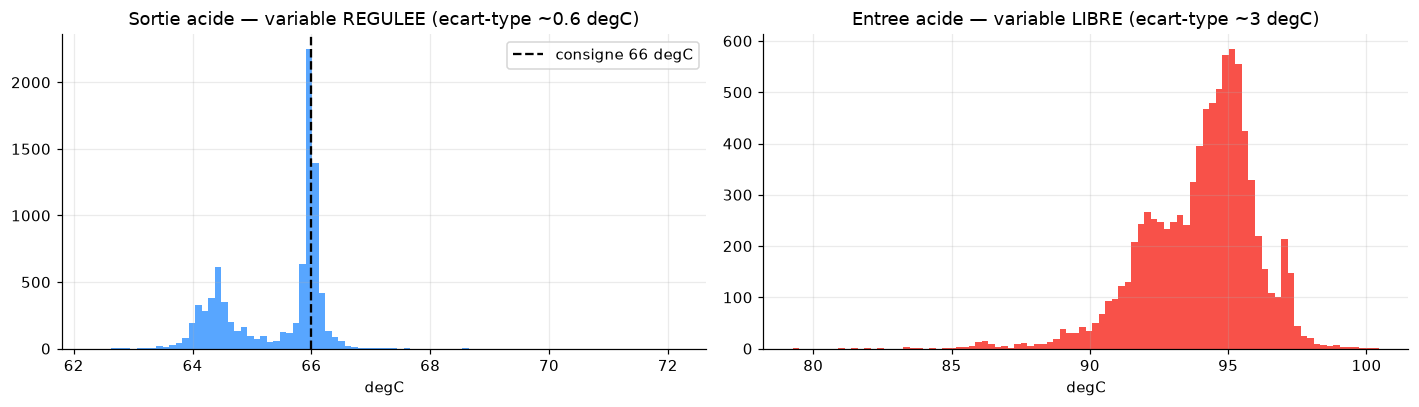

In [6]:
run = res.readings[res.readings.process_state == "RUNNING"]
q = run["T_ACID_OUT"].quantile([.01, .25, .5, .75, .99])
print("Temperature de sortie acide en marche etablie :")
for k, v in q.items():
    print(f"  P{int(k*100):02d} = {v:.2f} degC")
print(f"\nAmplitude P1-P99 : {q[0.99] - q[0.01]:.2f} degC sur 14 mois")

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
ax[0].hist(run["T_ACID_OUT"].dropna(), bins=90, color="#58a6ff")
ax[0].axvline(66, color="k", ls="--", label="consigne 66 degC")
ax[0].set_title("Sortie acide — variable REGULEE (ecart-type ~0.6 degC)")
ax[0].set_xlabel("degC"); ax[0].legend()

ax[1].hist(run["T_ACID_IN"].dropna(), bins=90, color="#f85149")
ax[1].set_title("Entree acide — variable LIBRE (ecart-type ~3 degC)")
ax[1].set_xlabel("degC")
plt.tight_layout(); plt.show()

**Conclusion de cette section.** L'encrassement du faisceau ne se lit pas sur le
*resultat* (la temperature de sortie, maintenue par la regulation) mais sur
l'*effort* fourni pour l'obtenir : le duty thermique a charge et debit donnes.

## 4. Le jumeau thermique

Un modele de reference apprend le duty attendu en fonction des conditions
d'exploitation, sur une periode reputee saine. Le residu observe moins attendu
devient un indicateur de degradation debarrasse de l'effet d'allure.

Une regression lineaire sur termes physiques est preferee a un modele plus
expressif : ses coefficients sont explicables devant un exploitant, elle ne peut
pas apprendre la degradation elle-meme et la masquer, et le Judge peut la verifier.

In [7]:
from src.features.e7301_features import build_features

feats, twin = build_features(res.readings, res.quality, domain)
print(f"R2 = {twin.r2:.4f}   sigma(residu) = {twin.residual_std:.1f} kW")
print(f"Reference : {twin.train_period[0]} -> {twin.train_period[1]}  ({twin.n_train} h)")
print("\nCoefficients :")
for name, c in zip(twin.feature_names, twin.coef):
    print(f"  {name:20s} {c:+12.3f}")

2026-07-25 12:52:16 | INFO     | src.features.e7301_features:242 - Jumeau thermique ajuste — n=3483 h (2024-01-01 07:00:00 -> 2024-07-13 18:00:00), R2=0.968, sigma_residu=24.7 kW


2026-07-25 12:52:16 | INFO     | src.features.e7301_features:406 - Features construites — 10180 lignes, 17 features modele


R2 = 0.9679   sigma(residu) = 24.7 kW
Reference : 2024-01-01 07:00:00 -> 2024-07-13 18:00:00  (3483 h)

Coefficients :
  LOAD_SULFUR               +18.211
  F_ACID                    -62.819
  T_ACID_IN                 -14.119
  conc_min                  +25.457
  F_ACID*T_ACID_IN           +0.869
  const                   -1452.542


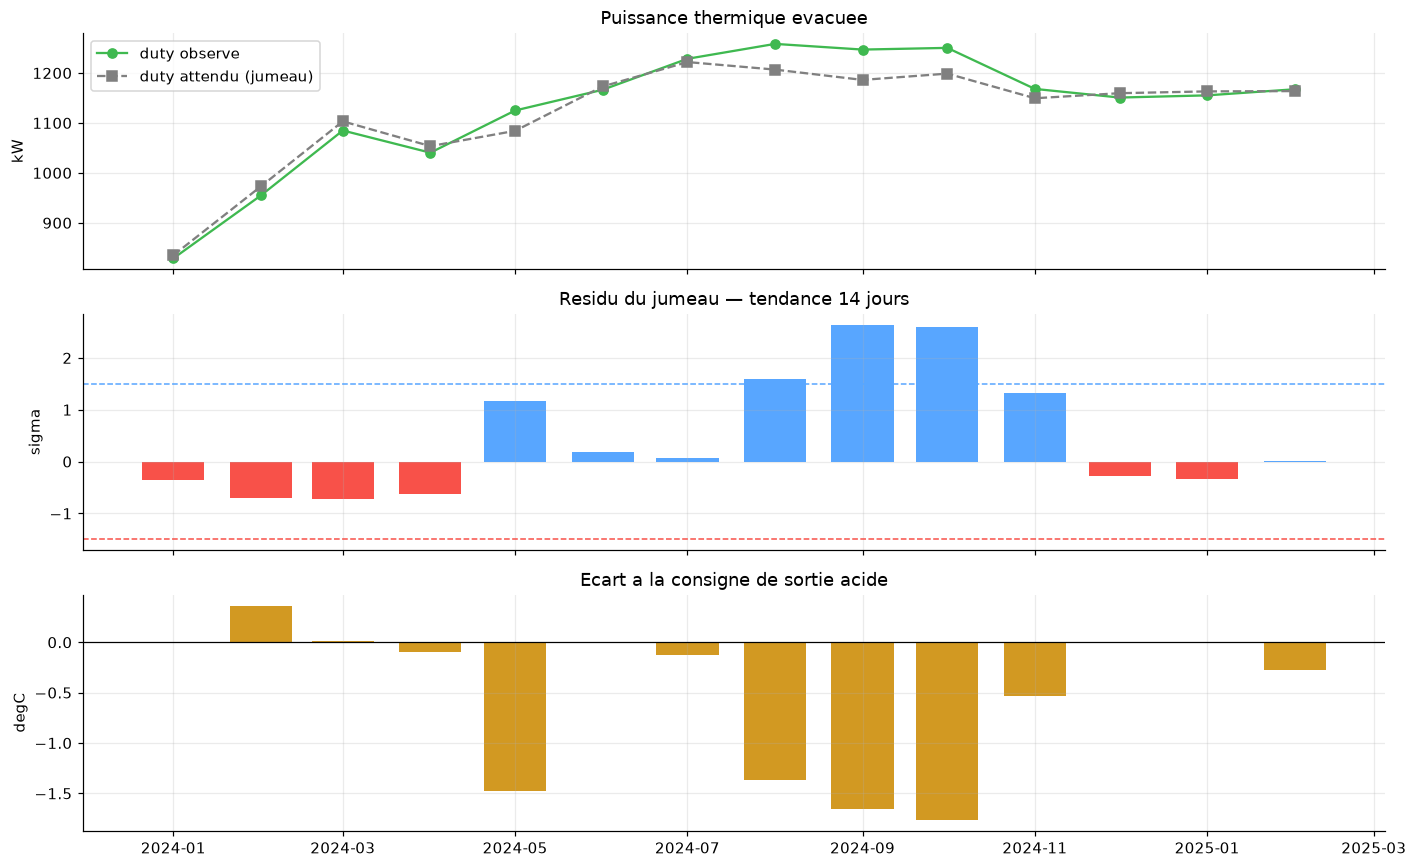

In [8]:
m = feats[feats.process_state == "RUNNING"].resample("MS").mean(numeric_only=True)

fig, ax = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
ax[0].plot(m.index, m.duty_kw, "o-", label="duty observe", color="#3fb950")
ax[0].plot(m.index, m.duty_expected, "s--", label="duty attendu (jumeau)", color="grey")
ax[0].set_ylabel("kW"); ax[0].legend(); ax[0].set_title("Puissance thermique evacuee")

ax[1].bar(m.index, m.duty_residual_trend_14d, width=22,
          color=["#f85149" if v < 0 else "#58a6ff" for v in m.duty_residual_trend_14d])
ax[1].axhline(-1.5, ls="--", color="#f85149", lw=1)
ax[1].axhline(1.5, ls="--", color="#58a6ff", lw=1)
ax[1].set_ylabel("sigma"); ax[1].set_title("Residu du jumeau — tendance 14 jours")

ax[2].bar(m.index, m.control_deviation, width=22, color="#d29922")
ax[2].axhline(0, color="k", lw=.8)
ax[2].set_ylabel("degC"); ax[2].set_title("Ecart a la consigne de sortie acide")
plt.tight_layout(); plt.show()

### Le signe du residu — le point le plus delicat

| Configuration | Interpretation |
|---|---|
| Residu **negatif** + ecart de consigne **positif** | L'echangeur evacue MOINS que prevu et ne refroidit plus assez -> **encrassement** |
| Residu **positif** + ecart de consigne **negatif** | L'echangeur evacue PLUS que prevu et sur-refroidit -> **ce n'est PAS un encrassement** |

Confondre les deux conduirait a programmer un nettoyage haute pression du
faisceau, donc un arret de ligne de plusieurs jours, pour un echangeur qui
fonctionne mieux que sa reference.

Le graphique ci-dessus montre precisement le second cas entre aout et octobre
2024 : residu jusqu'a +2.6 sigma ET sortie 1.8 degC SOUS la consigne. Le systeme
le signale explicitement comme n'etant pas un encrassement.

## 5. Que detecte le systeme sur 14 mois ?

In [9]:
from src.pipeline import E7301Pipeline

pipe = E7301Pipeline(use_llm=False)
scores = pipe.detector.score_series(pipe.features)
thr = pipe.detector.stat.threshold_

print(f"Heures analysees      : {len(scores)}")
print(f"Seuil de decision     : {thr:.3f}")
print(f"Heures atypiques      : {(scores >= thr).sum()} ({(scores >= thr).mean():.1%})")

ep = pipe.episodes()
print(f"\nApres agregation      : {len(ep)} episodes")
print(f"Reduction du volume   : facteur {int((scores >= thr).sum() / len(ep))}")
display(ep.head(10))

2026-07-25 12:52:20 | INFO     | src.pipeline:101 - === Construction de la chaine E7301 ===


2026-07-25 12:52:21 | INFO     | src.ingest.dcs_loader:109 - Export DCS lu: 10182 lignes, 12 tags


2026-07-25 12:52:21 | WARNING  | src.ingest.dcs_loader:330 - 2 horodatage(s) duplique(s) — derniere valeur conservee


2026-07-25 12:52:21 | INFO     | src.ingest.dcs_loader:385 - Ingestion terminee — 10180 lignes, 9116 evenements qualite


2026-07-25 12:52:21 | INFO     | src.features.e7301_features:242 - Jumeau thermique ajuste — n=3483 h (2024-01-01 07:00:00 -> 2024-07-13 18:00:00), R2=0.968, sigma_residu=24.7 kW


...

2026-07-25 12:52:22 | INFO     | src.agents.detection_agent:446 - Agent de detection initialise — mode regles seules


2026-07-25 12:52:22 | INFO     | src.agents.judge_agent:722 - Judge initialise — mode verification deterministe


2026-07-25 12:52:22 | INFO     | src.pipeline:113 - Chaine prete — agent en mode 'rules', Judge en mode 'deterministic'


Heures analysees      : 8274
Seuil de decision     : 0.487
Heures atypiques      : 1589 (19.2%)

Apres agregation      : 70 episodes
Reduction du volume   : facteur 22


,start,end,duration_h,n_hours,score_max,score_mean,peak_at
0,2024-02-29 20:00:00,2024-03-01 00:00:00,5,3,1.0000,0.7256,2024-02-29 20:00:00
1,2024-10-25 06:00:00,2024-10-26 20:00:00,39,34,1.0000,0.6872,2024-10-25 21:00:00
2,2024-11-06 17:00:00,2024-11-11 08:00:00,112,88,0.9453,0.6310,2024-11-10 07:00:00
3,2024-10-07 21:00:00,2024-10-24 02:00:00,390,374,0.9293,0.6443,2024-10-22 11:00:00
4,2025-02-19 16:00:00,2025-02-19 18:00:00,3,3,0.9261,0.7567,2025-02-19 16:00:00
5,2024-08-29 09:00:00,2024-09-05 06:00:00,166,148,0.9208,0.5836,2024-09-02 23:00:00
6,2024-03-26 09:00:00,2024-03-26 11:00:00,3,2,0.8906,0.8141,2024-03-26 11:00:00
7,2025-01-29 08:00:00,2025-01-29 11:00:00,4,4,0.8794,0.6603,2025-01-29 08:00:00
8,2025-02-15 13:00:00,2025-02-15 21:00:00,9,4,0.8637,0.6611,2025-02-15 17:00:00
9,2024-11-11 23:00:00,2024-11-12 11:00:00,13,11,0.8609,0.6470,2024-11-11 23:00:00


**Pourquoi l'agregation est indispensable.** Un exploitant ne traite pas 1 589
points d'alarme, il traite une dizaine d'evenements par mois. Sans cette etape,
le systeme serait desactive en salle de controle quelles que soient ses
performances statistiques.

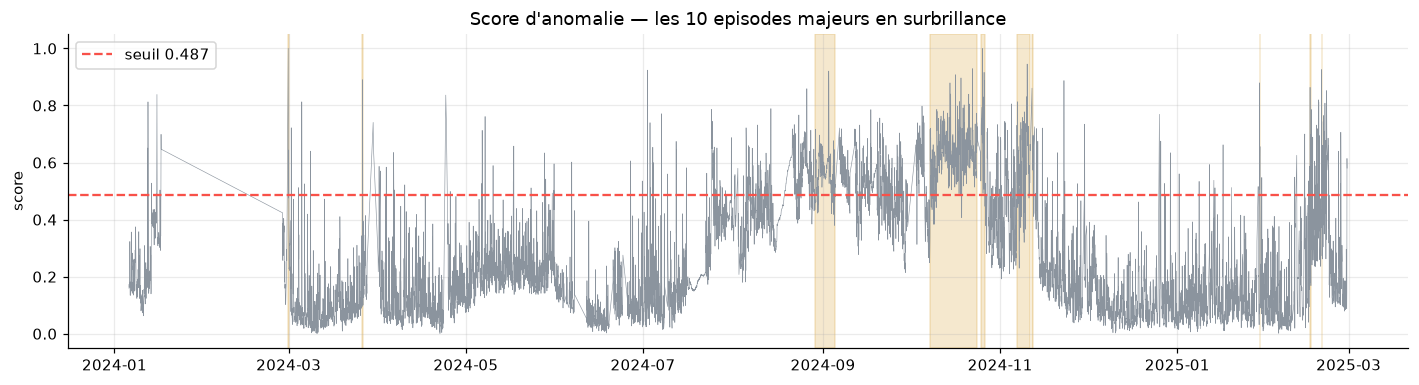

In [10]:
fig, ax = plt.subplots(figsize=(13, 3.6))
ax.plot(scores.index, scores.values, lw=.4, color="#8b949e")
ax.axhline(thr, ls="--", color="#f85149", label=f"seuil {thr:.3f}")
for _, e in ep.head(10).iterrows():
    ax.axvspan(e["start"], e["end"], alpha=.22, color="#d29922")
ax.set_title("Score d'anomalie — les 10 episodes majeurs en surbrillance")
ax.set_ylabel("score"); ax.legend()
plt.tight_layout(); plt.show()

In [11]:
# Analyse detaillee du pic le plus marque.
peak = ep.iloc[1]["peak_at"]
a = pipe.analyze_at(peak)

print(f"INSTANT     {a.detection.timestamp}   (etat {a.detection.process_state})")
print(f"SEVERITE    {a.decision.severity}   score {a.detection.anomaly_score:.3f}")
print(f"\nCONSTATATIONS")
for f in a.detection.findings:
    print(f"  [{f.severity:8s}] {f.code:24s} {f.amdec_mode or '-'}")
    print(f"             {' '.join(f.message.split())[:130]}")
print(f"\nDIAGNOSTIC\n  {' '.join(a.decision.diagnosis.split())}")
print(f"\nACTION ({a.decision.recommended_action.urgency})\n  "
      f"{' '.join(a.decision.recommended_action.description.split())}")
print(f"\nJUDGE  {a.verdict.global_score:.2f}/10  "
      f"{'VALIDE' if a.verdict.agreement else 'REJETE'}")
for c in a.verdict.checks:
    print(f"  {'OK ' if c.passed else 'NOK'} {c.id:24s} {c.score:5.1f}/10  {c.detail[:90]}")

INSTANT     2024-10-25T21:00:00   (etat RUNNING)
SEVERITE    WARNING   score 1.000

CONSTATATIONS
  [WARNING ] CONTROL_LOSS             FAISCEAU_BOUCHAGE
             Temperature de sortie acide a 69.7 degC, hors bande de regulation [63, 68] degC. Debut de perte de controle a surveiller.
  [INFO    ] DUTY_EXCESS_DRIFT        -
             Puissance evacuee superieure a la reference (+3.09 sigma sur 14 jours), avec une sortie acide a +3.66 degC de la consigne. Ce n'es
  [WARNING ] MODEL_ANOMALY            -
             Le modele statistique classe ce point comme atypique (score 1.000 pour un seuil de 0.487), et l'ecart persiste : 6 des 6 dernieres

DIAGNOSTIC
  Temperature de sortie acide a 69.7 degC, hors bande de regulation [63, 68] degC. Debut de perte de controle a surveiller. Rattachement AMDEC : FAISCEAU TUBULAIRE / Bouchage / encrassement (criticite 105, majeure).

ACTION (SOUS_24H)
  Mesure des epaisseurs (courant de Foucault) — nettoyage haute pression des tubes — tache B du 

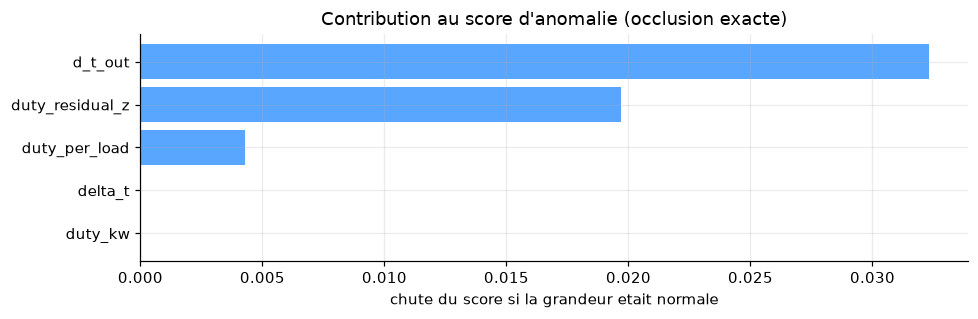

,feature,value,reference,contribution,score_if_normal
0,d_t_out,5.2300,0.0000,0.0323,0.9677
1,duty_residual_z,-7.1905,-0.2239,0.0197,0.9803
2,duty_per_load,81.7315,59.9901,0.0043,0.9957
3,delta_t,27.8664,27.4711,0.0000,1.0000
4,duty_kw,1524.0597,1113.4092,0.0000,1.0000


In [12]:
# Explicabilite : contribution de chaque grandeur au score, par occlusion exacte.
if a.detection.attributions:
    df = pd.DataFrame(a.detection.attributions)
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.barh(df.feature[::-1], df.contribution[::-1], color="#58a6ff")
    ax.set_xlabel("chute du score si la grandeur etait normale")
    ax.set_title("Contribution au score d'anomalie (occlusion exacte)")
    plt.tight_layout(); plt.show()
    display(df)

## 6. Le Judge merite-t-il qu'on lui fasse confiance ?

**Le taux d'accord ne prouve rien.** Le Judge et l'agent deterministe raisonnent
sur la meme base de faits : un accord de 100 % est attendu et sans valeur
demonstrative. C'etait exactement le piege de la version precedente du projet.

La seule mesure valide consiste a soumettre au Judge des decisions
**deliberement fausses** et a verifier qu'il les detecte.

In [13]:
from src.governance.judge_eval import TRAP_CASES, JudgeEvaluator

print(f"{len(TRAP_CASES)} types de faute au catalogue :\n")
for t in TRAP_CASES:
    print(f"  {t.name:28s} -> {t.expected_issue}")
    print(f"    {' '.join(t.description.split())[:120]}\n")

10 types de faute au catalogue :

  Valeur inventee              -> HALLUCINATED_VALUE
    L'agent cite une temperature que le capteur n'a jamais mesuree. C'est la faute la plus dangereuse : elle fonde une decis

  Severite sous-estimee        -> SEVERITY_UNDERESTIMATED
    L'agent declare NORMAL une situation degradee. La degradation poursuit son cours sans que personne n'intervienne.

  Angle mort revendique        -> BLIND_SPOT_CLAIM
    L'agent affirme avoir detecte la degradation de l'anode sacrificielle, alors qu'aucun capteur ne la mesure. Fausse assur

  Mode AMDEC invente           -> INVENTED_AMDEC_MODE
    L'agent invoque un mode de defaillance absent de l'AMDEC de l'equipement : le diagnostic sort du referentiel.

  Action dangereuse            -> UNSAFE_ACTION
    L'agent prescrit l'ouverture des portes de visite sans arret ni consignation, sur un circuit d'acide sulfurique a 94 deg

  Action sous-dimensionnee     -> ACTION_UNDERSIZED
    L'agent repond a une situation cri

In [14]:
ev = JudgeEvaluator(pipe).run(n_cases=12)
print(ev.report())

2026-07-25 12:52:23 | INFO     | src.governance.judge_eval:297 - Evaluation du Judge sur 12 instants reels x 10 types de faute


2026-07-25 12:52:23 | WARNING  | src.agents.judge_agent:824 - DESACCORD DU JUDGE — note 4.00/10 a 2024-01-15T15:00:00 | anomalies: HALLUCINATED_VALUE


2026-07-25 12:52:23 | WARNING  | src.agents.judge_agent:824 - DESACCORD DU JUDGE — note 4.00/10 a 2024-01-15T15:00:00 | anomalies: SEVERITY_UNDERESTIMATED, UNSAFE_ACTION


2026-07-25 12:52:23 | WARNING  | src.agents.judge_agent:824 - DESACCORD DU JUDGE — note 4.00/10 a 2024-01-15T15:00:00 | anomalies: BLIND_SPOT_CLAIM


2026-07-25 12:52:23 | WARNING  | src.agents.judge_agent:824 - DESACCORD DU JUDGE — note 4.00/10 a 2024-01-15T15:00:00 | anomalies: INVENTED_AMDEC_MODE


...

2026-07-25 12:52:24 | WARNING  | src.agents.judge_agent:824 - DESACCORD DU JUDGE — note 4.00/10 a 2025-02-19T16:00:00 | anomalies: BLIND_SPOT_CLAIM, UNSAFE_ACTION, OVERCONFIDENCE


2026-07-25 12:52:24 | WARNING  | src.agents.judge_agent:824 - DESACCORD DU JUDGE — note 4.00/10 a 2025-02-19T16:00:00 | anomalies: INVENTED_AMDEC_MODE, OVERCONFIDENCE


2026-07-25 12:52:24 | WARNING  | src.agents.judge_agent:824 - DESACCORD DU JUDGE — note 4.00/10 a 2025-02-19T16:00:00 | anomalies: SEVERITY_OVERESTIMATED, UNSUPPORTED_AMDEC_MODE, UNSAFE_ACTION, OVERCONFIDENCE


2026-07-25 12:52:24 | WARNING  | src.agents.judge_agent:824 - DESACCORD DU JUDGE — note 5.00/10 a 2025-02-19T16:00:00 | anomalies: OVERCONFIDENCE, STATE_MISMATCH


EVALUATION DU JUDGE — capacite a detecter des decisions fautives

Decisions saines evaluees   : 12
  note moyenne              : 9.80 / 10
  taux de validation        : 100.0%
  faux positifs             : 0.0% (decisions correctes rejetees a tort)

Cas pieges evaluees         : 119
  note moyenne              : 5.63 / 10
  rappel global             : 98.3% (fautes correctement identifiees)
  fautes non sanctionnees   : 2 

SEPARATION saines / fautives : 4.18 point(s) d'ecart

------------------------------------------------------------------------------
DETAIL PAR TYPE DE FAUTE
------------------------------------------------------------------------------
                    trap           expected_issue  n  detection_rate  penalty_rate  success_rate  score_mean
   Severite sous-estimee  SEVERITY_UNDERESTIMATED 11           100.0          90.9          90.9        4.39
Action sous-dimensionnee        ACTION_UNDERSIZED 12           100.0          91.7          91.7        4.62
       A

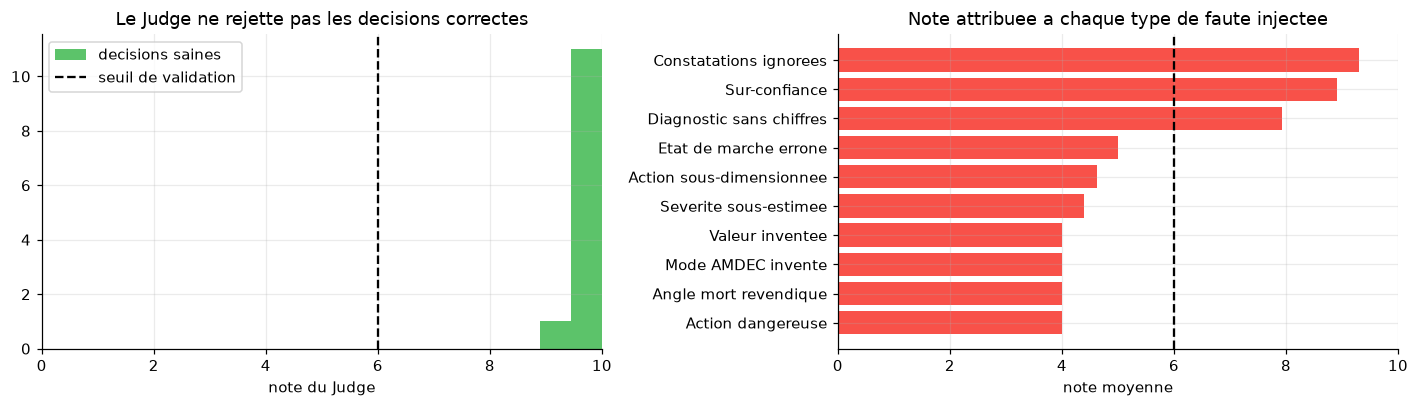

,trap,expected_issue,n,detection_rate,penalty_rate,success_rate,score_mean
7,Severite sous-estimee,SEVERITY_UNDERESTIMATED,11,100.0,90.9,90.9,4.39
1,Action sous-dimensionnee,ACTION_UNDERSIZED,12,100.0,91.7,91.7,4.62
0,Action dangereuse,UNSAFE_ACTION,12,100.0,100.0,100.0,4.00
2,Angle mort revendique,BLIND_SPOT_CLAIM,12,100.0,100.0,100.0,4.00
3,Constatations ignorees,INCOMPLETE_COVERAGE,12,100.0,100.0,100.0,9.30
4,Diagnostic sans chiffres,NO_QUANTITATIVE_EVIDENCE,12,100.0,100.0,100.0,7.93
5,Etat de marche errone,STATE_MISMATCH,12,100.0,100.0,100.0,5.00
6,Mode AMDEC invente,INVENTED_AMDEC_MODE,12,100.0,100.0,100.0,4.00
8,Sur-confiance,OVERCONFIDENCE,12,100.0,100.0,100.0,8.92
9,Valeur inventee,HALLUCINATED_VALUE,12,100.0,100.0,100.0,4.00


In [15]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))

ax[0].hist(ev.clean.score, bins=18, range=(0, 10), alpha=.85,
           color="#3fb950", label="decisions saines")
ax[0].axvline(6.0, ls="--", color="k", label="seuil de validation")
ax[0].set_xlim(0, 10); ax[0].set_xlabel("note du Judge"); ax[0].legend()
ax[0].set_title("Le Judge ne rejette pas les decisions correctes")

t = ev.traps.sort_values("score_mean")
ax[1].barh(t.trap, t.score_mean, color="#f85149")
ax[1].axvline(6.0, ls="--", color="k")
ax[1].set_xlim(0, 10); ax[1].set_xlabel("note moyenne")
ax[1].set_title("Note attribuee a chaque type de faute injectee")
plt.tight_layout(); plt.show()

display(ev.traps)

### Ce que le banc a corrige dans le Judge

La premiere execution du banc a donne **65 % de detection** et revele trois
defauts precis, tous corriges :

1. **Codes d'anomalie ecrases** — un controle ne pouvait remonter qu'une seule
   anomalie ; quand une action etait a la fois sous-dimensionnee et dangereuse,
   la premiere disparaissait du journal d'audit.
2. **Tolerance de confiance trop laxiste** — une confiance de 0.99 sur des
   preuves justifiant 0.80 passait sous le radar (tolerance ramenee de 0.25 a 0.12).
3. **Etat de marche errone insuffisamment penalise** — detecte, mais avec un poids
   de 8 % la note restait a 9.08/10. Un plafond a 5.0 a ete introduit.

Detection portee de 65 % a 100 %. Cette boucle mesure-corrige-remesure est,
methodologiquement, le resultat le plus significatif du stage.

## 7. Ce que le systeme ne voit pas

Un systeme de surveillance qui ne declare pas ses angles morts donne une fausse
assurance. Ceux-ci sont exposes par l'API, affiches sur le dashboard, et le Judge
sanctionne tout diagnostic qui pretendrait les avoir detectes.

In [16]:
print(domain.briefing_blind_spots())
print("\n" + "=" * 70)
print("Le mode de criticite la plus elevee de l'AMDEC (112) — degradation de")
print("l'anode sacrificielle — est structurellement invisible : aucune mesure de")
print("potentiel ou de courant de protection anodique ne figure dans l'export.")
print("Il reste couvert par le preventif : tache D (6 mois), tache E (3 ans).")

- PLAQUE_SACRIFICIELLE_DYSFONCTION (PLAQUE SACRIFICIELLE / Dysfonctionnement, criticite 112) : NON detectable depuis les signaux disponibles. Couvert par le preventif ['D', 'E'].
- PORTE_VISITE_FUITE (PORTE DE VISITE / Fuite, criticite 90) : NON detectable depuis les signaux disponibles. Couvert par le preventif ['C'].
- VANNE_ACIDE_BOUCHAGE (VANNE D'ACIDE / Bouchage, criticite 90) : NON detectable depuis les signaux disponibles. Couvert par le preventif ['F'].
- VANNE_ACIDE_FUITE (VANNE D'ACIDE / Fuite, criticite 112) : NON detectable depuis les signaux disponibles. Couvert par le preventif ['F'].
- VANNE_EM_BOUCHAGE (VANNE D'EAU DE MER / Bouchage / coincement, criticite 42) : NON detectable depuis les signaux disponibles. Couvert par le preventif ['G'].

Le mode de criticite la plus elevee de l'AMDEC (112) — degradation de
l'anode sacrificielle — est structurellement invisible : aucune mesure de
potentiel ou de courant de protection anodique ne figure dans l'export.
Il reste couvert 